- Dataset: [**SMS Spam Collection Dataset - Kaggle**](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

- Youtube Video: [**Project 17. Spam Mail Prediction using Machine Learning with Python | Machine Learning Projects**](https://www.youtube.com/watch?v=rxkGItX5gGE)

In [1]:
# =============================================================================
# INSTALL REQUIRED PACKAGES
# =============================================================================

!pip install kagglehub nltk wordcloud scikit-learn xgboost matplotlib seaborn pandas numpy ipywidgets --quiet

# =============================================================================
# IMPORT ALL LIBRARIES
# =============================================================================

# Basic data handling
import os
import pandas as pd
import numpy as np
import pickle
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import Counter

# Machine learning
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

# Additional components
from wordcloud import WordCloud
from xgboost import XGBClassifier
import ipywidgets as widgets
from IPython.display import display

# Kaggle integration
import kagglehub
from kagglehub import KaggleDatasetAdapter
from google.colab import userdata

In [2]:
# =============================================================================
# DOWNLOAD NLTK DATA AND RESOURCES
# =============================================================================

print("Downloading NLTK resources...")
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK downloads completed!")

NLTK downloads completed!


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# =============================================================================
# LOAD DATASET FROM KAGGLE
# =============================================================================

# Setup Kaggle authentication
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USER")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

# Load dataset with proper encoding
print("Loading dataset...")
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/sms-spam-collection-dataset",
    "spam.csv",
    pandas_kwargs={"encoding": "latin-1"}
)

print(f"Dataset loaded with shape: {df.shape}")
print("First few rows:")
df.head()

Loading dataset...
Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Dataset loaded with shape: (5572, 5)
First few rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# =============================================================================
# CLEAN AND PREPARE DATA
# =============================================================================

# Show original structure
print("Original columns:", df.columns.tolist())

# Remove empty or unused columns
df.drop(df.columns[[2, 3, 4]], axis=1, inplace=True)

# Rename columns for better understanding
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

# Remove duplicate messages
print(f"Duplicates before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after removal: {df.duplicated().sum()}")

print(f"Final dataset shape: {df.shape}")
df.head()

Original columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
Duplicates before removal: 403
Duplicates after removal: 0
Final dataset shape: (5169, 2)


,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Label mapping: {'ham': np.int64(0), 'spam': np.int64(1)}

Class distribution:
target
0    4516
1     653
Name: count, dtype: int64


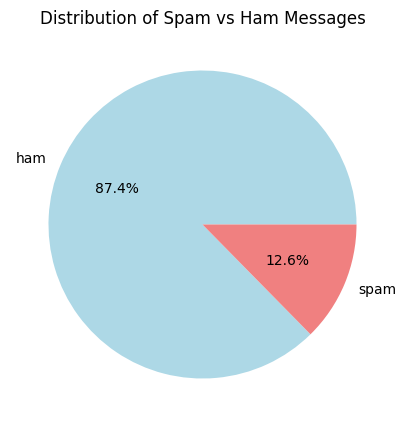

In [5]:
# =============================================================================
# PREPROCESS DATA FOR MODELING
# =============================================================================

# Convert text labels to numbers (ham=0, spam=1)
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Show class distribution
print("\nClass distribution:")
print(df['target'].value_counts())

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Distribution of Spam vs Ham Messages')
plt.show()

In [6]:
# =============================================================================
# CREATE NEW FEATURES FROM TEXT
# =============================================================================

# Add text length features
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(sent_tokenize(x)))

print("Dataset with new features:")
print(df[['text', 'target', 'num_characters', 'num_words', 'num_sentences']].head())

# Show statistics
print("\nBasic statistics of new features:")
print(df[['num_characters', 'num_words', 'num_sentences']].describe())

Dataset with new features:
                                                text  target  num_characters  \
0  Go until jurong point, crazy.. Available only ...       0             111   
1                      Ok lar... Joking wif u oni...       0              29   
2  Free entry in 2 a wkly comp to win FA Cup fina...       1             155   
3  U dun say so early hor... U c already then say...       0              49   
4  Nah I don't think he goes to usf, he lives aro...       0              61   

   num_words  num_sentences  
0         24              2  
1          8              2  
2         37              2  
3         13              1  
4         15              1  

Basic statistics of new features:
       num_characters    num_words  num_sentences
count     5169.000000  5169.000000    5169.000000
mean        78.977945    18.455794       1.965564
std         58.236293    13.324758       1.448541
min          2.000000     1.000000       1.000000
25%         36.000000     9

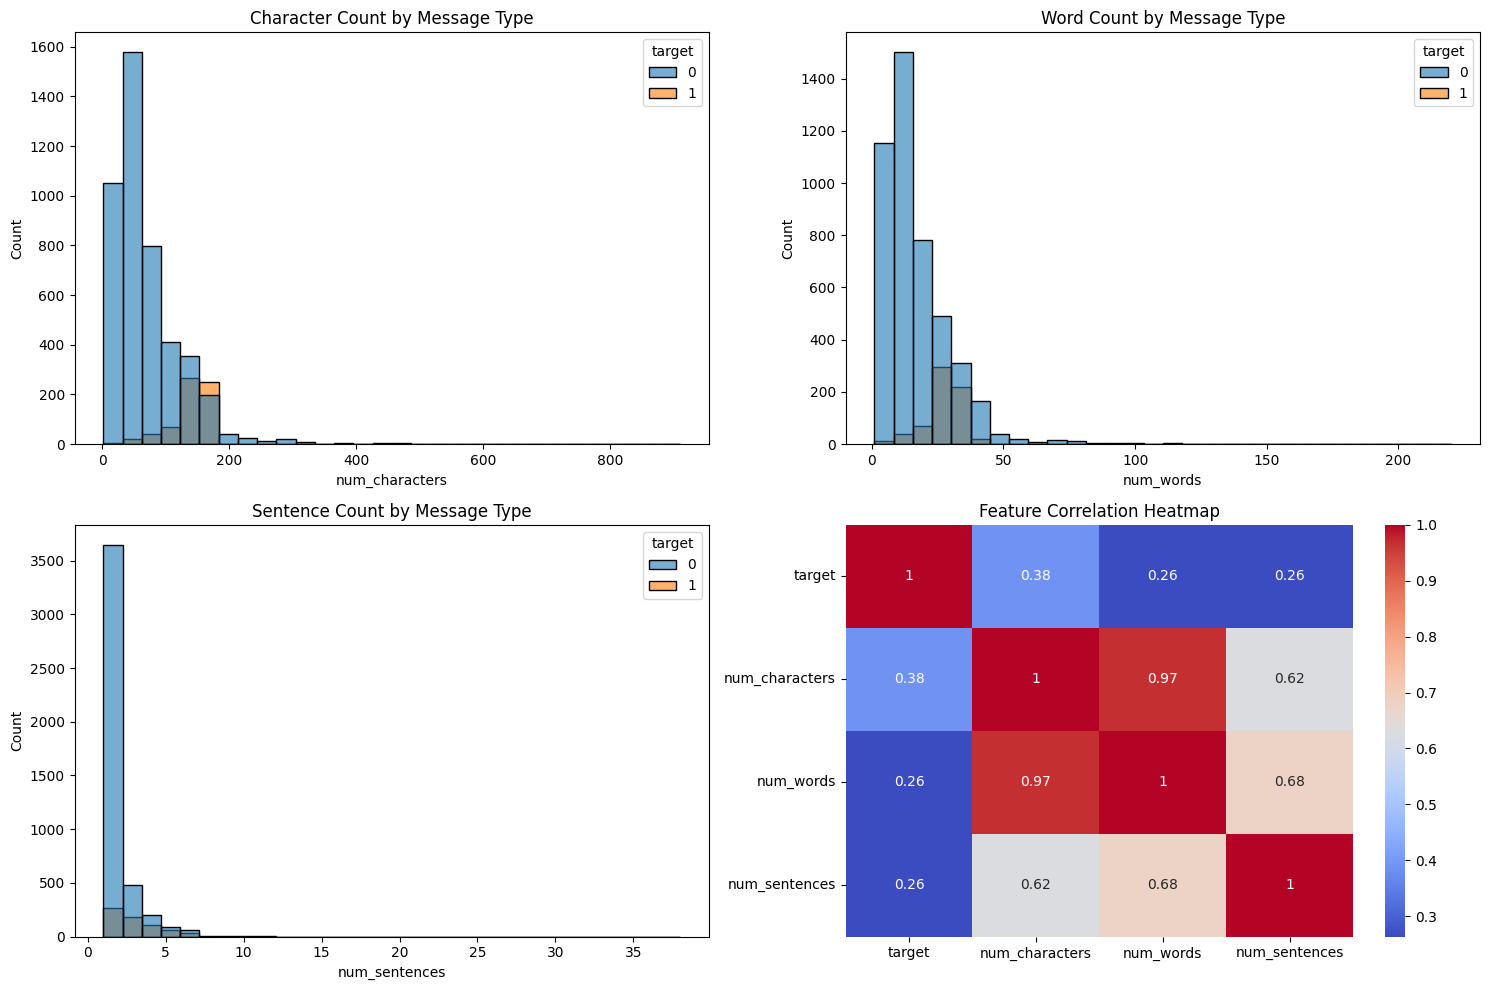

In [7]:
# =============================================================================
# VISUALIZE DATA PATTERNS
# =============================================================================

# Create subplots for multiple visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Character count distribution
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='num_characters', hue='target', bins=30, alpha=0.6)
plt.title('Character Count by Message Type')

# Plot 2: Word count distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='num_words', hue='target', bins=30, alpha=0.6)
plt.title('Word Count by Message Type')

# Plot 3: Sentence count distribution
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='num_sentences', hue='target', bins=30, alpha=0.6)
plt.title('Sentence Count by Message Type')

# Plot 4: Correlation heatmap
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# TEXT CLEANING AND PREPROCESSING FUNCTION
# =============================================================================

def transform_text(text):
    """
    Clean and preprocess text through multiple steps:
    1. Convert to lowercase
    2. Split into words (tokenize)
    3. Remove special characters and numbers
    4. Remove common stopwords and punctuation
    5. Reduce words to root form (stemming)
    """
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Split into individual words
    text = word_tokenize(text)

    # Step 3: Keep only alphabetic words
    text = [word for word in text if word.isalpha()]

    # Step 4: Remove stopwords and punctuation
    stop_words = set(stopwords.words('english'))
    text = [word for word in text if word not in stop_words and word not in string.punctuation]

    # Step 5: Apply stemming
    ps = PorterStemmer()
    text = [ps.stem(word) for word in text]

    # Join back into a single string
    return " ".join(text)

# Apply preprocessing to all messages
print("Preprocessing text messages...")
df['transformed_text'] = df['text'].apply(transform_text)
print("Text preprocessing completed!")

# Show before and after examples
print("\nOriginal vs Transformed Text Examples:")
for i in range(3):
    print(f"Original: {df['text'].iloc[i][:50]}...")
    print(f"Cleaned:  {df['transformed_text'].iloc[i][:50]}...")
    print("-" * 40)

Preprocessing text messages...
Text preprocessing completed!

Original vs Transformed Text Examples:
Original: Go until jurong point, crazy.. Available only in b...
Cleaned:  go jurong point crazi avail bugi n great world la ...
----------------------------------------
Original: Ok lar... Joking wif u oni......
Cleaned:  ok lar joke wif u oni...
----------------------------------------
Original: Free entry in 2 a wkly comp to win FA Cup final tk...
Cleaned:  free entri wkli comp win fa cup final tkt may text...
----------------------------------------


In [9]:
# =============================================================================
# CONVERT TEXT TO NUMERICAL FEATURES
# =============================================================================

# Use TF-IDF to convert text to numerical features
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

# Get target variable
y = df['target'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Feature matrix shape: (5169, 3000)
Number of features: 3000
Number of samples: 5169
Training set: (4135, 3000)
Testing set: (1034, 3000)


In [10]:
# =============================================================================
# TRAIN AND COMPARE NAIVE BAYES MODELS
# =============================================================================

print("Training Naive Bayes models...")

# Initialize different Naive Bayes variants
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

# Train and evaluate each model
models = [gnb, mnb, bnb]
model_names = ['GaussianNB', 'MultinomialNB', 'BernoulliNB']

for name, model in zip(model_names, models):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    print(f"{name:15} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}")

Training Naive Bayes models...
GaussianNB      - Accuracy: 0.8694, Precision: 0.5071
MultinomialNB   - Accuracy: 0.9700, Precision: 1.0000
BernoulliNB     - Accuracy: 0.9778, Precision: 0.9752



Training multiple models for comparison...
Training Naive Bayes...
Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training K-Neighbors...
Training XGBoost...

MODEL PERFORMANCE RANKING:
                 Model  Accuracy  Precision
0          Naive Bayes  0.970019   1.000000
5          K-Neighbors  0.911992   1.000000
4        Random Forest  0.970986   0.982143
2                  SVM  0.973888   0.974359
1  Logistic Regression  0.955513   0.969388
6              XGBoost  0.968085   0.956522
3        Decision Tree  0.929400   0.821782

⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
⭐ BEST MODEL: Naive Bayes
⭐ Best Precision: 1.0000
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐


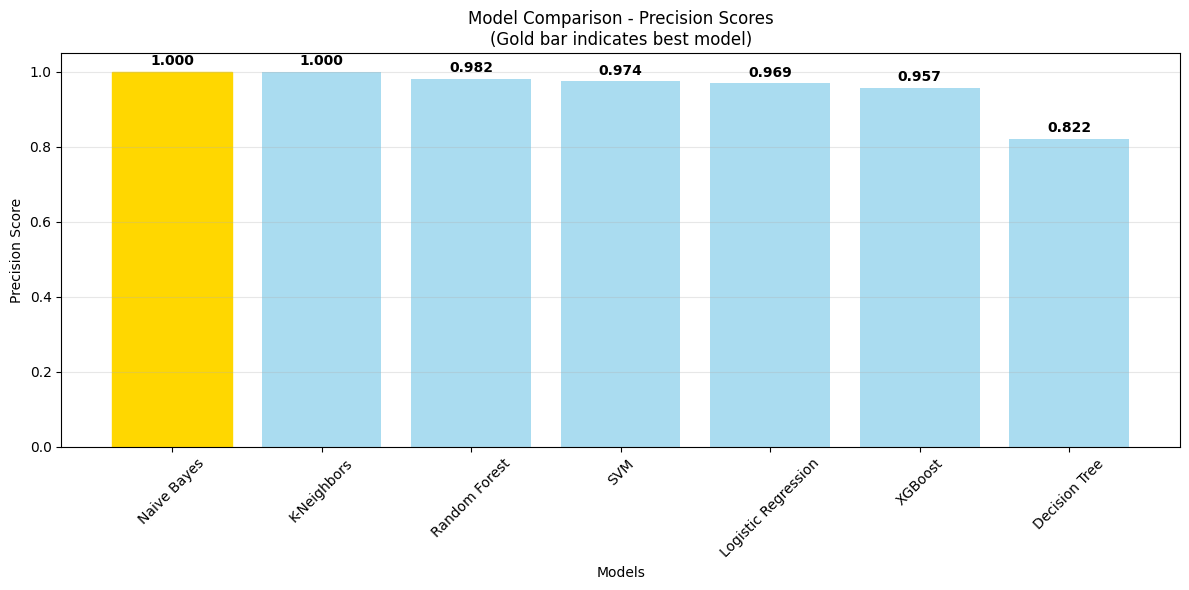


✅ 'Naive Bayes' selected as the best model and will be saved.


In [11]:
# =============================================================================
# COMPARE MULTIPLE MACHINE LEARNING MODELS
# =============================================================================

print("\nTraining multiple models for comparison...")

# Define various classifiers
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(solver='liblinear', penalty='l1', random_state=2),
    'SVM': SVC(kernel='sigmoid', gamma=1.0, random_state=2),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=2),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=2),
    'K-Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(n_estimators=50, random_state=2)
}

# Train and evaluate all models
results = []
best_model_name = None
best_precision = 0
best_model = None

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # Check if this is the best model so far
    if precision > best_precision:
        best_precision = precision
        best_model_name = name
        best_model = clf

    results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision})

# Create results dataframe and display
results_df = pd.DataFrame(results).sort_values('Precision', ascending=False)
print("\n" + "="*50)
print("MODEL PERFORMANCE RANKING:")
print("="*50)
print(results_df)

# Display the best model information
print("\n" + "⭐"*60)
print(f"⭐ BEST MODEL: {best_model_name}")
print(f"⭐ Best Precision: {best_precision:.4f}")
print("⭐"*60)

# Visualize results
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Model'], results_df['Precision'], color='skyblue', alpha=0.7)

# Highlight the best model bar
best_index = results_df[results_df['Model'] == best_model_name].index[0]
bars[best_index].set_color('gold')
bars[best_index].set_alpha(1.0)

plt.title('Model Comparison - Precision Scores\n(Gold bar indicates best model)')
plt.xlabel('Models')
plt.ylabel('Precision Score')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, precision in zip(bars, results_df['Precision']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{precision:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Store the best model for saving in next snippet
mnb = best_model  # This will be used in the model saving step
print(f"\n✅ '{best_model_name}' selected as the best model and will be saved.")

In [12]:
# =============================================================================
# SAVE THE TRAINED MODEL AND VECTORIZER
# =============================================================================

# Save the TF-IDF vectorizer and best model
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

print("Model and vectorizer saved successfully!")
print("Files created: vectorizer.pkl, model.pkl")

Model and vectorizer saved successfully!
Files created: vectorizer.pkl, model.pkl


In [13]:
# =============================================================================
# CREATE PREDICTION FUNCTION
# =============================================================================

def predict_spam(message):
    """
    Predict whether a message is spam or not

    Args:
        message (str): Input SMS message

    Returns:
        str: Prediction result
    """
    # Preprocess the input message
    transformed_text = transform_text(message)

    # Convert to numerical features
    text_vector = tfidf.transform([transformed_text]).toarray()

    # Make prediction
    prediction = mnb.predict(text_vector)

    # Return readable result
    if prediction[0] == 1:
        return "🚫 SPAM"
    else:
        return "✅ NOT SPAM"

# Test the function
test_message = "Congratulations! You won a $1000 prize. Claim now!"
result = predict_spam(test_message)
print(f"Test message: '{test_message}'")
print(f"Prediction: {result}")

Test message: 'Congratulations! You won a $1000 prize. Claim now!'
Prediction: 🚫 SPAM


In [14]:
# =============================================================================
# TEST WITH EXAMPLE MESSAGES
# =============================================================================

print("=" * 60)
print("TESTING WITH EXAMPLE MESSAGES")
print("=" * 60)

# Define test messages
test_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Text YES to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account has been compromised. Click here to secure it now!",
    "Mom, I'll be home late today. Don't wait for me for dinner.",
    "FREE entry to win £5000 cash prize! Reply NOW to claim your reward!",
    "Hi, this is Dr. Smith's office reminding you of your appointment tomorrow at 3 PM.",
    "You've been selected for a special offer! Call now to claim your free iPhone!",
    "Can you pick up some milk on your way home?",
    "Your package will be delivered today between 2-4 PM. Please be available.",
    "You are the lucky winner! Claim your prize money now by clicking the link!"
]

print("Testing spam detection system:\n")

# Test each message
for i, message in enumerate(test_messages, 1):
    result = predict_spam(message)
    print(f"{i:2d}. {result} - {message[:70]}...")

print("\n" + "=" * 60)
print("🎯 SPAM DETECTION SYSTEM READY FOR USE!")
print("=" * 60)

TESTING WITH EXAMPLE MESSAGES
Testing spam detection system:

 1. 🚫 SPAM - Congratulations! You've won a $1000 Walmart gift card. Text YES to cla...
 2. ✅ NOT SPAM - Hey, are we still meeting for lunch tomorrow?...
 3. 🚫 SPAM - URGENT: Your bank account has been compromised. Click here to secure i...
 4. ✅ NOT SPAM - Mom, I'll be home late today. Don't wait for me for dinner....
 5. 🚫 SPAM - FREE entry to win £5000 cash prize! Reply NOW to claim your reward!...
 6. ✅ NOT SPAM - Hi, this is Dr. Smith's office reminding you of your appointment tomor...
 7. 🚫 SPAM - You've been selected for a special offer! Call now to claim your free ...
 8. ✅ NOT SPAM - Can you pick up some milk on your way home?...
 9. ✅ NOT SPAM - Your package will be delivered today between 2-4 PM. Please be availab...
10. 🚫 SPAM - You are the lucky winner! Claim your prize money now by clicking the l...

🎯 SPAM DETECTION SYSTEM READY FOR USE!


In [15]:
# =============================================================================
# CREATE INTERACTIVE PREDICTION INTERFACE
# =============================================================================

print("Launching interactive spam detector...")

# Create input widget
text_input = widgets.Textarea(
    value='',
    placeholder='Enter your SMS message here...',
    description='Message:',
    layout=widgets.Layout(width='80%', height='100px')
)

# Create prediction button
predict_button = widgets.Button(
    description="Check for Spam",
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

# Create output display area
output_area = widgets.Output()

# Define button click action
def on_predict_click(button):
    with output_area:
        # Clear previous output
        output_area.clear_output()

        # Get input message
        message = text_input.value.strip()

        # Check if message is provided
        if not message:
            print("❌ Please enter a message to check.")
            return

        # Show processing message
        print("🔍 Analyzing message...")

        # Get prediction
        result = predict_spam(message)

        # Display result
        print(f"\n📊 Result: {result}")

        # Add additional info based on result
        if "SPAM" in result:
            print("⚠️  This message appears to be spam!")
        else:
            print("👍 This message appears to be legitimate.")

# Connect button to function
predict_button.on_click(on_predict_click)

# Display all widgets
print("Enter a message below and click 'Check for Spam':")
display(text_input)
display(predict_button)
display(output_area)

Launching interactive spam detector...
Enter a message below and click 'Check for Spam':


Textarea(value='', description='Message:', layout=Layout(height='100px', width='80%'), placeholder='Enter your…

Button(button_style='primary', description='Check for Spam', layout=Layout(width='200px'), style=ButtonStyle()…

Output()